In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [5]:
from typing_extensions import TypedDict

class BatsmanState(TypedDict):
    fours: float     
    sixes: float     
    runs: float      
    summery: str     
    bp: float        
    balls: float     
    sr: float        
    bpb: float       

In [29]:
def cal_sr(state : BatsmanState):
  sr = 100*state['runs']/state['balls']

  return {'sr' : round(sr,2)}

In [30]:
def cal_bp(state : BatsmanState):
  bp = (4*state['fours']+6*state['sixes'])/state['runs']

  return {'bp' : round(100*bp,2)}

In [24]:
def cal_bpb(state: BatsmanState):
  bpb = state['balls']/(state['fours']+state['sixes'])

  return {'bpb' : bpb}

In [10]:
def summery(state: BatsmanState):
  summery = f""" 
strike rate: {state['sr']} \n
boundary percentage: {state['bp']} \n
balls per boudary: {state['bpb']}

"""
  return {'summery' : summery}

In [31]:
graph = StateGraph(BatsmanState)

graph.add_node('cal_sr',cal_sr)
graph.add_node('cal_boundary_percentage',cal_bp)
graph.add_node('cal_bpb' , cal_bpb)

graph.add_node('summery',summery)

graph.add_edge(START,'cal_sr')
graph.add_edge(START,'cal_boundary_percentage')
graph.add_edge(START,'cal_bpb')

graph.add_edge('cal_sr','summery')
graph.add_edge('cal_boundary_percentage','summery')
graph.add_edge('cal_bpb','summery')

graph.add_edge('summery',END)

workflow = graph.compile()




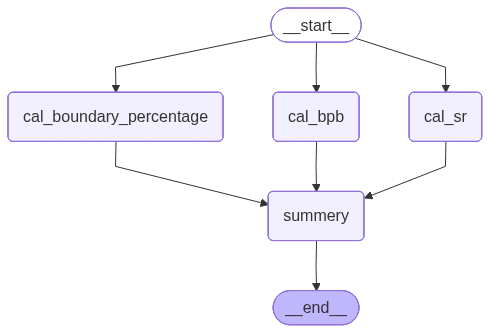

In [32]:
workflow

In [ ]:
initial_state = {
  'fours' : 10,
  'sixes':5,
  'runs' : 300,
  'balls' : 180
}
final_state = workflow.invoke(initial_state)

print(final_state['summery'])

 
strike rate: 166.67 

boundary percentage: 23.33 

balls per boudary: 12.0


